**Import Libraries**

In [2]:
# !pip install pandas tabula-py
# !java -version
import pandas as pd
import os
import tabula
from tabula.io import read_pdf
import warnings
warnings.filterwarnings("ignore")

**Set the Directory**

- Choose PDF 1: (Roozaneh.pdf)

In [18]:
os.chdir("../3.OUT_PDF")
pdf1 = "1-Roozaneh.pdf"

In the **first step**, I begin the process by identifying and storing the headers of each table.
- Define a list of Persian keywords that will be used to recognize table headers based on the content of the first column.
- Create a dictionary to store the detected headers along with their corresponding row index and page number.

The following image shows an example of how I detect a table header:

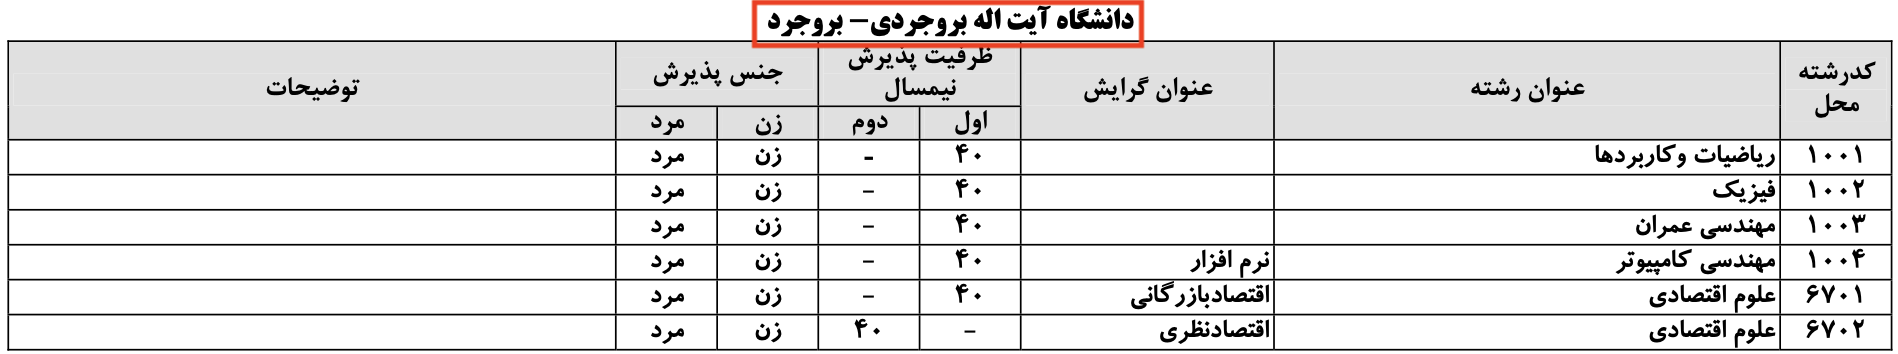

In [21]:
keywords = ["دانشگاه", "آموزشكده", "دانشكده", "مجتمع", "مركز", "ادامه"]

uni_headers = {}

for page in range(22,23):
    content = tabula.read_pdf(pdf1, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():
        
        if page == 22 & idx < 36:
            break

        if any(str(cell).startswith(tuple(keywords)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])

            uni_name = str(col[0])
            uni_headers[(page, idx)] = uni_name

uni_headers = list(uni_headers.items())

uni_headers[:5]

[((22, 1), 'دانشگاه مذاهب اسلامي*')]

The following function takes three inputs:
- Current Page Number
- Current Row Index
- List of header entries

This function returns the most recent matching university name for the provided row.

In [4]:
def find_university(page, idx, header_items):
    current_uni = None
    for (h_page, h_idx), h_name in header_items:
        if h_page < page:

            continue
        if h_page > page:

            break

        if idx >= h_idx:
            current_uni = h_name
        else:
            break
    return current_uni

In the **next step**, I will continue the process by identifying and storing the desired rows from each table.
- Identify rows that begin with a number.
- Remove the last cell from each row.
- Apply the university function for matching.
- Store the resulting rows to create a dataset.

The following image shows an example of how I iterate through the rows:

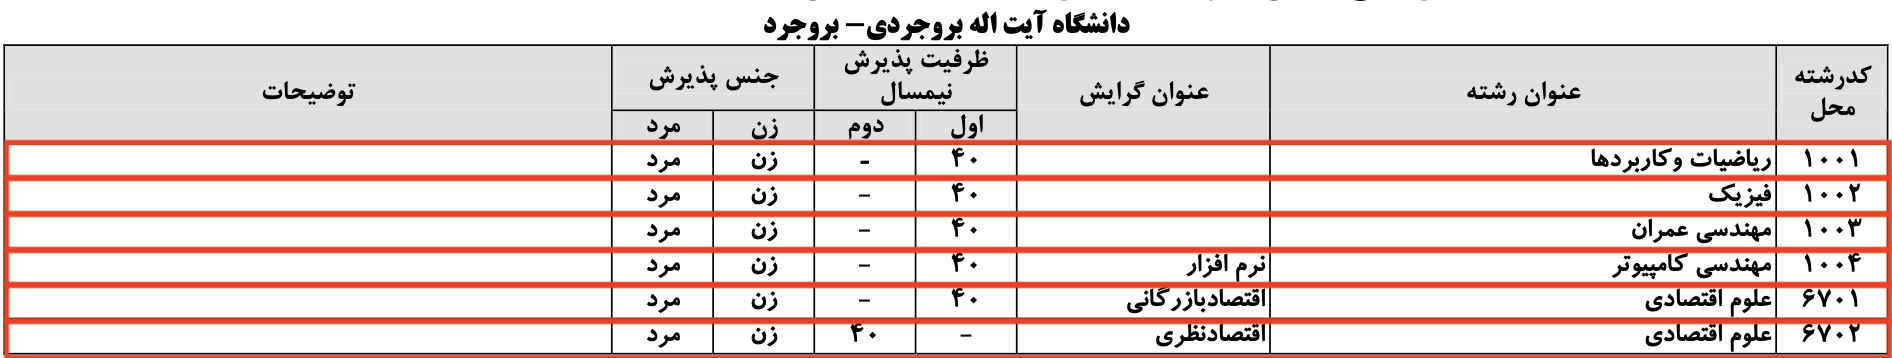

In [ ]:
page_list = []

for page in range(1, 23):
    content = tabula.read_pdf(pdf1, lattice = False,
                               guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                              pandas_options = {'header': None}, pages = str(page))[0]
    university = ''

    for idx, col in content.iterrows():

        if str(col[7]).isdigit():
            university = find_university(page, idx, uni_headers)
            row_list = list(col.values)
            row_list = row_list[+1:] 
            row_list += [university] 
            row_list.reverse()
            if str(col[7]) == "2223":
                break
            # print(row_list)
            page_list.append(row_list)

In [7]:
df = pd.DataFrame(page_list, columns = ['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                           'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap'])

df.head(5)

,university,Programme-Code,Programme-Major-Name,Major-Type,Capacity-first,Capacity-Second,Female-Cap,Male-Cap
0,دانشگاه آيت اله بروجردي- بروجرد,1001,رياضيات وكاربردها,NaN,40,-,زن,مرد
1,دانشگاه آيت اله بروجردي- بروجرد,1002,فيزيك,NaN,40,-,زن,مرد
2,دانشگاه آيت اله بروجردي- بروجرد,1003,مهندسي عمران,NaN,40,-,زن,مرد
3,دانشگاه آيت اله بروجردي- بروجرد,1004,مهندسي كامپيوتر,نرم افزار,40,-,زن,مرد
4,دانشگاه آيت اله بروجردي- بروجرد,6701,علوم اقتصادي,اقتصادبازرگاني,40,-,زن,مرد


In [8]:
os.chdir("../4.OUT_TABLE")
df.to_csv("1.Roozaneh.csv", index = False, encoding = "utf-8-sig")

- Choose PDF 2: (Mahroum.pdf)

In [ ]:
pdf2 = "2-Mahroum.pdf"

keywords = ["مخصوص", "ادامه"]

uni_headers = {}

for page in range(1,3):
    content = tabula.read_pdf(pdf2, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if any(str(cell).startswith(tuple(keywords)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])
            
            uni_name = str(col[0])
            uni_headers[(page, idx)] = uni_name

uni_headers = list(uni_headers.items())

uni_headers[:5]

[((1, 29), 'مخصوص داوطلبان بومي استان ايلام'),
 ((1, 41), 'مخصوص داوطلبان بومي استان بوشهر'),
 ((1, 47), 'مخصوص داوطلبان بومي استان چهارمحال و بختياري'),
 ((1, 53), 'مخصوص داوطلبان بومي استان سيستان و بلوچستان'),
 ((1, 67), 'مخصوص داوطلبان بومي استان كردستان')]

---

- Choose PDF 3: (Farhangian.pdf)

In [ ]:
os.chdir("../3.OUT_PDF")
pdf3 = "3-Farhangian.pdf"

keywords = ["مخصوص", "ادامه"]

uni_headers = {}

for page in range(1, 4):
    content = tabula.read_pdf(pdf3, lattice = False, guess = False,
                                  pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if page == 3 and idx >= 55:
            break

        if any(str(cell).startswith(tuple(keywords)) for cell in col):
            # print( "page:", page, "index:", idx, "university name:", col[0])
            
            uni_name = str(col[0])
            uni_headers[(page, idx)] = uni_name

uni_headers = list(uni_headers.items())

uni_headers[:5]

page: 1 index: 18 university name: مخصوص داوطلبان بومي استان آذربايجان شرقي
page: 1 index: 26 university name: مخصوص داوطلبان بومي استان آذربايجان غربي
page: 1 index: 31 university name: مخصوص داوطلبان بومي استان اردبيل
page: 1 index: 36 university name: مخصوص داوطلبان بومي استان اصفهان
page: 1 index: 42 university name: مخصوص داوطلبان بومي استان البرز
page: 1 index: 47 university name: مخصوص داوطلبان بومي استان ايلام
page: 1 index: 50 university name: مخصوص داوطلبان بومي استان بوشهر
page: 1 index: 55 university name: مخصوص داوطلبان بومي استان تهران
page: 1 index: 63 university name: مخصوص داوطلبان بومي استان چهارمحال و بختياري
page: 1 index: 67 university name: مخصوص داوطلبان بومي استان خراسان جنوبي
page: 1 index: 72 university name: مخصوص داوطلبان بومي استان خراسان رضوي
page: 2 index: 1 university name: ادامه مخصوص داوطلبان بومي استان خراسان رضوي
page: 2 index: 9 university name: مخصوص داوطلبان بومي استان خراسان شمالي
page: 2 index: 13 university name: مخصوص داوطلبان بومي استان خوزست

---

- Choose PDF 4: (Kardani-Farhanian.pdf)

This PDF does not have any header, making it easy to iterate through the rows to extract the table.

The area of this table has been modified to easily separate the cells. 

The same above pattern is also present here.

The following image shows an example of how I iterate through the rows:

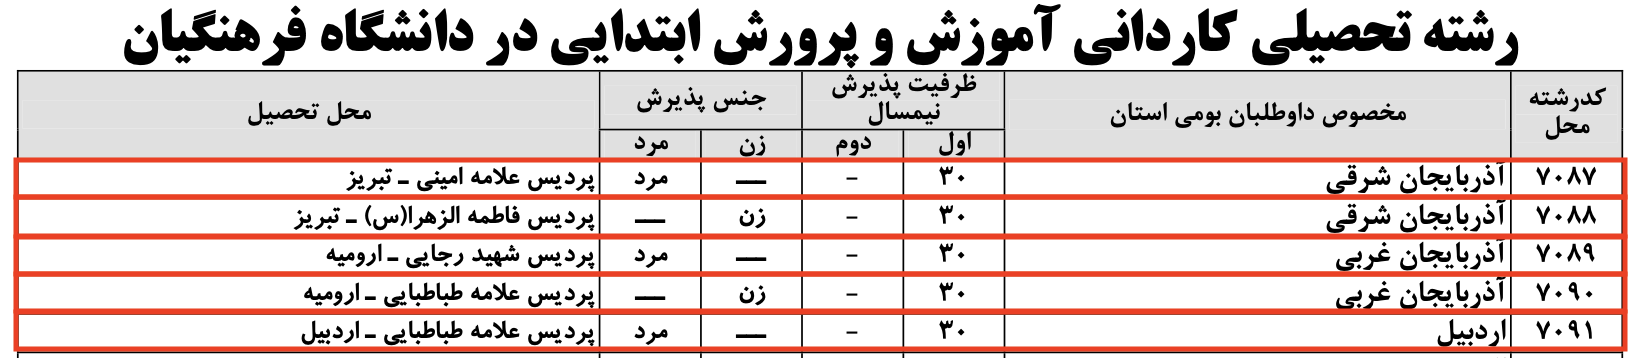

In [2]:
os.chdir("../3.OUT_PDF")
pdf4 = "4-Kardani-Farhanian.pdf"

kardani_farhangian_list = []

for page in range(1, 3):
    content = tabula.read_pdf(pdf4, lattice = False,
                               guess = False, columns = [236, 264, 293, 321, 349, 491, 522],
                              pandas_options = {'header': None}, pages = str(page))[0]

    for idx, col in content.iterrows():

        if str(col[6]).isdigit():
            row_list = list(col.values)
            row_list.reverse()
            row_list = row_list[+1:]
            # print(row_list) 
            kardani_farhangian_list.append(row_list)

df4 = pd.DataFrame(kardani_farhangian_list,
                   columns = ["Programme-Code", "Province", "Capacity-first",
                               "Capacity-Second", "Female-Cap", "Male-Cap", "Location"])

df4.head(5)
            

,Programme-Code,Province,Capacity-first,Capacity-Second,Female-Cap,Male-Cap,Location
0,7087,آذربايجان شرقي,30,-,ـــ,مرد,پرديس علامه اميني ـ تبريز
1,7088,آذربايجان شرقي,30,-,زن,ـــ,پرديس فاطمه الزهرا)س( ـ تبريز
2,7089,آذربايجان غربي,30,-,ـــ,مرد,پرديس شهيد رجايي ـ اروميه
3,7090,آذربايجان غربي,30,-,زن,ـــ,پرديس علامه طباطبايي ـ اروميه
4,7091,اردبيل,30,-,ـــ,مرد,پرديس علامه طباطبايي ـ اردبيل


Save this file as a CSV in the **"OUT_TABLE"** folder.

In [3]:
os.chdir("../4.OUT_TABLE")
df4.to_csv("4.Kardani-Farhangian.csv", index = False, encoding = "utf-8-sig")

---

- Choose PDF 7: (Nimeh-Hozouri.pdf)

This PDF does not have any header, making it easy to iterate through the rows to extract the table.

The area of this table has been modified to easily separate the cells. 

The same above pattern is also present here.

The following image shows an example of how I iterate through the rows:

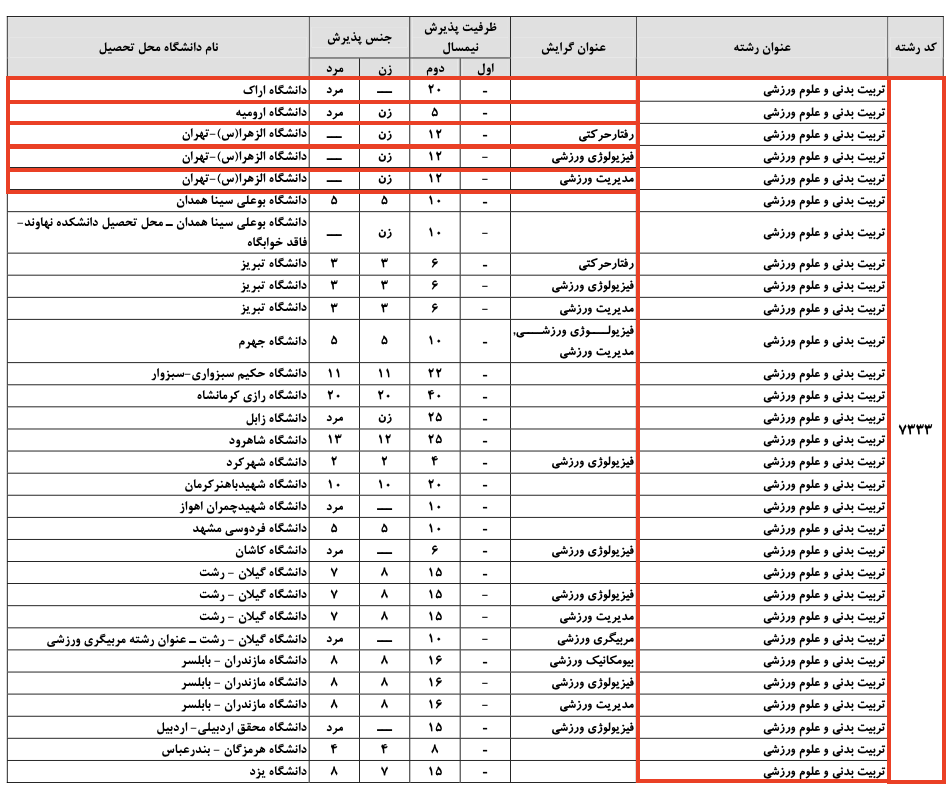

In [44]:
os.chdir("../3.OUT_PDF")
pdf7 = "7-Nimeh_Hozouri.pdf"

nimeh_hozouri_list = []

for page in range(1, 3):
    content = tabula.read_pdf(pdf7, lattice = False,
                               guess = False, columns = [204, 233, 261, 289, 317, 389, 530],
                              pandas_options = {'header': None}, pages = str(page))[0]
    if page == 1:

        for idx, col in content.iterrows():

            if str(col[6]) == "تربيت بدني و علوم ورزشي":
                row_list = list(col.values)
                row_list.reverse()
                row_list[0] = 7333
                if pd.isna(row_list[7]):
                    row_list[7] = "دانشگاه بوعلي سينا همدان ـ محل تحصيل دانشكده نهاوند-فاقد خوابگاه"
                if row_list[7] == "دانشگاه جهرم":
                    row_list[2] = "فيزيولــــوژي ورزشــــي, مديريت ورزشي"
                # print(row_list)
                nimeh_hozouri_list.append(row_list)
    
    else:
        for idx, col in content.iterrows():

            if str(col[7]).isdigit():
                row_list = list(col.values)
                row_list.reverse()
                if row_list[0] == "7363" or row_list[0] == "7364" or row_list[0] == "7365":
                    row_list[7] = "دانشگاه اروميه"
                if row_list[0] == "7366":
                    row_list[7] = "دانشگاه علامه طباطبايي - تهران"
                if row_list[0] == "7367":
                    row_list[7] = "دانشگاه كردستان - سنندج"
                if row_list[0] == "7368":
                    row_list[7] = "موسسه اموزشي وپژوهشي امام خميني)ره(- قم"
                # print(row_list)
                nimeh_hozouri_list.append(row_list)


df7 = pd.DataFrame(nimeh_hozouri_list,
                   columns = ["Programme-Code", "Programme-Major-Name", "Major-Type",
                               "Capacity-first", "Capacity-Second", "Female-Cap", "Male-Cap", "University Location"])
df7.head(5)

,Programme-Code,Programme-Major-Name,Major-Type,Capacity-first,Capacity-Second,Female-Cap,Male-Cap,University Location
0,7333,تربيت بدني و علوم ورزشي,NaN,-,20,ـــ,مرد,دانشگاه اراك
1,7333,تربيت بدني و علوم ورزشي,NaN,-,5,زن,مرد,دانشگاه اروميه
2,7333,تربيت بدني و علوم ورزشي,رفتارحركتي,-,12,زن,ـــ,دانشگاه الزهرا)س-(تهران
3,7333,تربيت بدني و علوم ورزشي,فيزيولوژي ورزشي,-,12,زن,ـــ,دانشگاه الزهرا)س-(تهران
4,7333,تربيت بدني و علوم ورزشي,مديريت ورزشي,-,12,زن,ـــ,دانشگاه الزهرا)س-(تهران


Save this file as a CSV in the **"OUT_TABLE"** folder.

In [ ]:
os.chdir("../4.OUT_TABLE")
df7.to_csv("7.Nimeh-Hozouri.csv", index = False, encoding = "utf-8-sig")

In [ ]:
for page in range(1,2):
    content = tabula.read_pdf(pdf1, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(page))[0]
    page_list = []
    university = ''
    for idx, rowcol in content.iterrows():
        if rowcol[7] == "محل":
            row_after = content.iloc[idx+2:]

            stop_idx = row_after.index[row_after.iloc[:, 4].eq("صفحه")]
            if len(stop_idx):
                row_after = row_after.loc[:stop_idx[0] - 1]

            for _, r in row_after.iterrows():
                row_list = list(r.values)
                print(row_list)

In [ ]:
pfx = ["دانشگاه", "آموزشكده", "دانشكده", "مجتمع", "مركز", "ادامه"]

for page in range(40, 41):
    content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(page))[0]
    page_list = []
    university = ''
    for idx, rowcol in content.iterrows():
        # # print("hello", index)
        # if rowcol.isna().sum() >= 1 and rowcol[7] != "محل":

        #     uni_header = ''
            
        #     for i in range(7, -1, -1):
        #         if type(rowcol[i]) == str:
        #             uni_header += rowcol[i]
        #     if any(uni_header.strip().startswith(prefix) for prefix in pfx):
        #     # if "دانشگاه" in uni_header or "آموزشكده" in uni_header or "دانشكده" in uni_header or "مجتمع" in uni_header or "مركز" in uni_header:
        #         university = uni_header
                # print("Page:", pp, "Row Number:", index, "Uni Name:", university)

            #################################

        if rowcol[7] == "محل":
            row_after = content.iloc[idx+2:]

            stop_idx = row_after.index[row_after.iloc[:, 4].eq("صفحه")]
            if len(stop_idx):
                row_after = row_after.loc[:stop_idx[0] - 1]

            for _, r in row_after.iterrows():
                row_list = list(r.values)
                row_list += [university]
                row_list.reverse()

                code_col = row_list[1]

                # if str(code_col).isdigit():
                    # code_col = int(code_col)
                # print(code_col)


                ##########################

                # if code_col.startswith("1","2","3","4","5","6","7","8","9","0") or code_col == "nan":
                #     row_list = row_list

                ##########################



                page_list.append(row_list)
                print(row_list)
                
                # print(page_list[-1])


In [ ]:
content

In [ ]:
for pp in range(20, 42):
    content = tabula.read_pdf(path, lattice=False, guess=False,
                              columns=[205, 233, 261, 290, 318, 389, 531],
                              pandas_options={'header': None}, pages=str(pp))[0]
    page_list = []
    university = ''
    print("page", pp)
    
    for index, rowcol in content.iterrows():
        if rowcol.isna().sum() >= 1 and rowcol[7] != "محل":
            uni_header = ''
            for i in range(7, -1, -1):
                if isinstance(rowcol[i], str):
                    uni_header += rowcol[i]

            if uni_header.strip().startswith(("دانشگاه", "ادامه دانشگاه")):
                university = uni_header.strip()
                print(index, university)

In [ ]:
df = pd.DataFrame(columns=['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                           'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap', 'Notes'])
for pp in range(20, 21):
  content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(pp))[0]
  page_list = []
  university = ''
  for index, row in content.iterrows():
    if row[7] == "محل":
        row_after = content.iloc[index+2:]

        for _, r in row_after.iterrows():
            row_list = list(r.values)
            row_list += [university]
            row_list = row_list[::-1]
            page_list += [row_list]
    # elif pd.isna(row[7]) and pd.isna(row[6]):
    elif row.isna().sum() >= 6: 
      temp_university = ''
      for i in range(7, -1, -1):
        if type(row[i]) == str:
          temp_university += row[i]
      if "دانشگاه" in temp_university:
        university = temp_university
  df1 = pd.DataFrame(page_list, columns=['university', 'Programme-Code', 'Programme-Major-Name', 'Major-Type',
                            'Capacity-first', 'Capacity-Second', 'Female-Cap', 'Male-Cap', 'Notes'])
  df = pd.concat([df, df1], ignore_index = True)


In [ ]:
for pp in range(20, 21):
  content = tabula.read_pdf(path, lattice = False, guess = False, columns = [205, 233, 261, 290, 318, 389, 531],
                                  pandas_options={'header': None}, pages = str(pp))[0]
  page_list = []
  university = ''

  for index, row in content.iterrows():
    if row[7] == "محل":
        row_after = content.iloc[index+2:]

        for _, r in row_after.iterrows():
            row_list = list(r.values)
            row_list += [university]
            row_list = row_list[::-1]
            page_list += [row_list]
            
            if r.isna().sum() >= 5 and r[7] != "محل":
              print('test')
              # temp_university = ''
              # for i in range(7, -1, -1):
              #   if type(row[i]) == str:
              #     print('hello')
              #     temp_university += row[i]
              #     print('tmp university so far:', temp_university)
              #   if "دانشگاه" in temp_university:
              #     print("temp_university:", temp_university)
              #     print(30*'-')
              #     university = temp_university
            # print(page_list)

    # elif pd.isna(row[7]) and pd.isna(row[6]): 
    if row.isna().sum() >= 3:
      temp_university = ''
      for i in range(7, -1, -1):
        if type(row[i]) == str:
          temp_university += row[i]
      if "دانشگاه" in temp_university:
        # print("temp_university:", temp_university)
        university = temp_university
        print(index)
        print("university:", university)
    